## Masking Tutorial

Spectral estimation with missing or masked data is a classic challenge in signal processing and time-series analysis. When you have gaps, traditional Fourier methods can have significant leakage as the assumption of a continuous, evenly spaced grid is broken.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
from kea.utils import binning
# modify_latex_rc()
# modify_latex_rc()

# Use the GPU for computing the SF, ACF, and performing Gaussian convolutions
from kea.utils import set_calculation_mode
set_calculation_mode(use_cpu=False, use_gpu=True)

from kea.simulator import make_field

# Set number of grid points
N = 1024
# Number of dimensions (two-dimensional)
D = 2
# We have the same number of grid points in each dimension
grid_dims = (N,N)

# Make the field
field = make_field(grid_dims,
                   spectrum_kwargs={'powerlaw': -8./3., 'cutoff_scale': 5.},
                   spectrum_function='cutoff_powerlaw',
                   seed=1, normalize_output=True)

Set statistic function calculation flags: (<CalculationMode.USE_GPU: 1>,)


**kea** provides a module to generate random masks for testing with the synthetic fields.

In [2]:
## Import the mask generator
from kea.simulator import mask

There are several options which we detail below. Of course, you could use your own mask.

Fraction of missing data: 0.5018987655639648


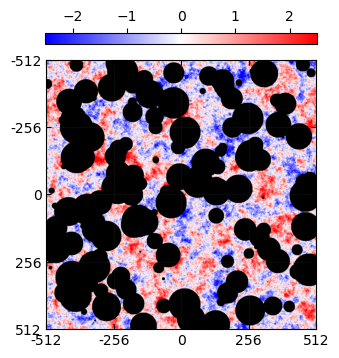

In [3]:
# Generate the mask
# 1's are valid pixels, 0 means invalid pixels
MISSING_FRACTION = 0.5
## Here are some examples:
## Generate random circles
generated_mask = mask.create_mask(grid_dims, 'circles', missing_fraction=MISSING_FRACTION)
## Generate a field mask using a synthetic field. This will produce interesting and non-trivial masks
# generated_mask = mask.create_mask(grid_dims, 'random_field', missing_fraction=MISSING_FRACTION, mask_kwargs={
#     'spectrum_function': 'pure_powerlaw',
#     'spectrum_kwargs': {'powerlaw': -11./3.},
# })
## Generate a circular cutoff
# generated_mask = mask.create_mask(grid_dims, 'outside', missing_fraction=MISSING_FRACTION)

# Set the masked points to NaN
nan_field = field.copy()
nan_field[generated_mask <= 0.] = np.nan

fraction = 1. - (np.nansum(generated_mask)/generated_mask.size)
print('Fraction of missing data:', fraction)

# Make colormap NaN pixels be black
cmap = mpl.colormaps.get('bwr')
cmap.set_bad('black')

## Plot the masked field
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
im = ax.imshow(nan_field, cmap=cmap, vmin=-2.5, vmax=2.5)
pretty_axes(ax)
ax.set_xticks(*make_ax_step(N, N//4))
ax.set_yticks(*make_ax_step(N, N//4))
cbar_ax = fig.add_axes([0.125, 0.925, 0.775, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')


Masking often breaks the assumption of homogeneity and isotropy of the field. Thus some PSD estimators may perform poorly depending on the masking conditions.

### Measure PSD

We now estimate the PSD using the different spectral estimators.

In [4]:
from kea.statistics.spectra import bin_spectrum, fourier_modal_spectrum, bt_modal_spectrum, esf_integrated_spectrum, transform_spectrum, dog_averaged_spectrum
from kea.statistics.statfunc import complete_symmetric_correlation_function, structure_function
from kea.utils import geometry
geometry.DEFAULT_PHYS_SCALE = 5.*np.pi

But first, we compute the "ground-truth" un-masked spectrum.

In [5]:
# Directly compute the power spectrum using the fast Fourier transform
true_kvec, true_fft_spectrum = fourier_modal_spectrum(field)
# Bin to the angle-averaged (average circular shells)
true_kp_averaged, true_fek_averaged, _ = bin_spectrum(true_kvec, true_fft_spectrum, 'averaged')

/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


The FFT spectrum does not handle NaN values. Thus, we must interpolate the missing values -- in this example we just set the missing values to zero.

The autocorrelation function does natively handle missing values, we compute the autocorrelation function by directly summing (available) pairs of points. Thus, for gapped data, we can still *estimate* the autocorrelation function. The fast Fourier transform is performed on the autocorrelation function which has no missing data.

Like the autocorrelation function, the structure function is computed using the available pairs of points. Thus the computed structure function is relatively complete (but may be a bad estimate depending on the statistics of the gaps). We can therefore use the ESF spectrum as a gap-aware spectral estimate.

The DoG method performs convolutions but weights the Gaussian kernel based on the missing data that is within its scope. Therefore, the DoG *can* deal with missing data remarkably well.

In [6]:
## (FFT)
zero_field = field.copy()
zero_field[generated_mask <= 0.] = 0.
# Directly compute the power spectrum using the fast Fourier transform
kvec, fft_spectrum = fourier_modal_spectrum(zero_field)
# Bin to the angle-averaged (average circular shells)
kp_averaged, fek_averaged, kp_widths = bin_spectrum(kvec, fft_spectrum, 'averaged')

/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


In [7]:
## (BT)
# First calculate the ACF
lags, acf_full = complete_symmetric_correlation_function(nan_field)
# Compute the correlogram
kvec_bt, bt_spectrum = bt_modal_spectrum(acf_full)
kbt_averaged, fekbt_averaged, _ = bin_spectrum(kvec_bt, bt_spectrum, 'averaged')

/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


In [8]:
## (ESF)
# First calculate the structure function
dx, dk = geometry.get_dxdk(grid_dims)
lags, sf2 = structure_function(nan_field)
sf2 = np.reshape(sf2, (N//2,)*D)*(dx[0]*N)**D
# Convert the lags that describe the grid indices into lags that represent the physical space
physical_lags = np.linalg.norm(lags*dx[0], axis=1).reshape((N//2,)*D)
print(np.shape(physical_lags), np.shape(sf2))

(512, 512) (512, 512)


In [9]:
from kea.utils.fitting import log_log_interpolate
# Bin the SF
bins_sf, binned_sf, _ = binning.bin_data(
    physical_lags, sf2, bin_func=np.nanmean, cut_excess=True, nan_small=False,
    min_bin=dx[0], log_space=True, max_bin=np.pi, bin_loc='true_center', num_bins=32)
bins_sf = bins_sf[np.isfinite(binned_sf)]
binned_sf = binned_sf[np.isfinite(binned_sf)]
binned_sf = log_log_interpolate(bins_sf, binned_sf, bins_sf)

/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


In [10]:
# Compute the ESF spectrum
ke, biased_esf_spectrum, esf_spectrum = esf_integrated_spectrum(
    bins_sf, binned_sf, D, fourier_wavenumbers=kp_averaged, b_factor=np.sqrt(2.))
# Convert from the ESF integrated spectrum to the averaged spectrum
ke_averaged, feke_averaged = transform_spectrum(
    ke, esf_spectrum, D, 'integrated', 'averaged', grid_dims, bin_widths=kp_widths, is_centered=True)

In [11]:
## (DoG)
# Directly compute the DoG spectrum using Gaussian convolutions
kd, dog_spectrum = dog_averaged_spectrum(nan_field, 1.-generated_mask)

Now, we compare the different techniques.

(1e-05, 10.0)

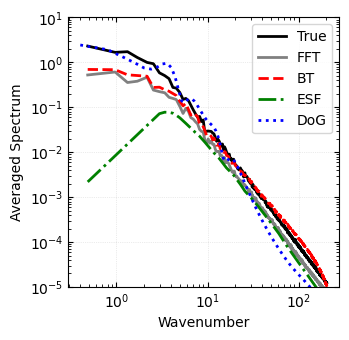

In [12]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(true_kp_averaged, true_fek_averaged, linestyle='-', color='black', linewidth=2., label='True')

ax.plot(kp_averaged, fek_averaged, linestyle='-', color='gray', linewidth=2., label='FFT')
ax.plot(kbt_averaged, fekbt_averaged, linestyle='--', color='red', linewidth=2., label='BT')
ax.plot(ke_averaged, feke_averaged, linestyle='-.', color='green', linewidth=2., label='ESF')
ax.plot(kd, dog_spectrum, linestyle=':', color='blue', linewidth=2., label='DoG')
pretty_axes(ax)
ax.loglog()
ax.set_ylabel('Averaged Spectrum')
ax.set_xlabel('Wavenumber')
ax.legend()

ax.set_ylim((1e-5, 1e1))
